In [198]:
import pandas as pd

In [199]:
df = pd.read_csv("vgsales.csv")

In [200]:
df.head(15)

,Nome,Plataforma,Ano,Gênero,Publisher,Vendas Globais (milhões)
0,Super Mario Galaxy,Wii,2007,Platform,Nintendo,11.35
1,Call of Duty: Modern Warfare 2,X360,2009,Shooter,Activision,13.52
2,Wii Sports Resort,Wii,2009,Sports,Nintendo,33.09
3,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,20.32
4,Minecraft,PC,2011,Misc,Mojang,25.50
5,The Last of Us,PS3,2013,Action,Sony,7.82
6,Red Dead Redemption 2,PS4,2018,Action-Adventure,Take-Two Interactive,17.22
7,FIFA 18,PS4,2017,Sports,Electronic Arts,10.94
8,God of War,PS4,2018,Action,Sony,11.00
9,The Witcher 3: Wild Hunt,PC,2015,Role-Playing,CD Projekt Red,6.47


In [201]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Nome                      72 non-null     str    
 1   Plataforma                72 non-null     str    
 2   Ano                       72 non-null     int64  
 3   Gênero                    72 non-null     str    
 4   Publisher                 72 non-null     str    
 5   Vendas Globais (milhões)  72 non-null     float64
dtypes: float64(1), int64(1), str(4)
memory usage: 3.5 KB


### Limpeza de Dados

In [202]:
df.isna().sum()

Nome                        0
Plataforma                  0
Ano                         0
Gênero                      0
Publisher                   0
Vendas Globais (milhões)    0
dtype: int64

#### Análise Exploratória de Dados

##### Agrupamento por Gênero

In [203]:
df['Gênero'].unique()

<StringArray>
[        'Platform',          'Shooter',           'Sports',
           'Action',             'Misc', 'Action-Adventure',
     'Role-Playing',         'Fighting',           'Racing',
           'Puzzle',       'Simulation',       'Action-RPG',
           'MMORPG',  'Survival Horror',             'MOBA',
    'Battle Royale',            'Party',     'Metroidvania']
Length: 18, dtype: str

Vamos considerar 'Action-Adventure' e 'Action-RPG' somente como 'Action'

In [204]:
df['Gênero'] = df['Gênero'].replace(['Action-Adventure','Action-RPG'],'Action')

In [205]:
df['Gênero'].unique()

<StringArray>
[       'Platform',         'Shooter',          'Sports',          'Action',
            'Misc',    'Role-Playing',        'Fighting',          'Racing',
          'Puzzle',      'Simulation',          'MMORPG', 'Survival Horror',
            'MOBA',   'Battle Royale',           'Party',    'Metroidvania']
Length: 16, dtype: str

In [206]:
generos = df.groupby('Gênero')

In [207]:
generos['Vendas Globais (milhões)'].sum().sort_values(ascending=False)

Gênero
Action             281.48
Shooter            209.16
Battle Royale      175.00
Role-Playing       150.80
Simulation         100.82
MOBA               100.00
Platform            94.68
Sports              84.03
Misc                77.52
Racing              67.00
Puzzle              46.81
Fighting            32.01
MMORPG              14.00
Party               10.00
Survival Horror      5.80
Metroidvania         3.00
Name: Vendas Globais (milhões), dtype: float64

##### Agrupamento por Console

In [208]:
df['Plataforma'].unique()

<StringArray>
[ 'Wii', 'X360',  'PS4',   'PC',  'PS3',   'NS',  'N64',   'PS',  'PS5',
   'DS',  'PS2',   'GB',  'NES', '2600', 'SNES',   'XB']
Length: 16, dtype: str

In [209]:
console = df.groupby('Plataforma')

In [222]:
console['Nome'].count().sort_values(ascending=False)

Plataforma
PC      21
PS4      9
X360     7
NS       6
PS2      4
Wii      4
DS       3
N64      3
SNES     3
PS       3
GB       2
PS3      2
PS5      2
2600     1
NES      1
XB       1
Name: Nome, dtype: int64

##### Coluna Década


In [211]:
def create_decade(ano: int) -> str:
    ano_str = str(ano)

    if ano < 2000:
        return f"Anos {ano_str[-2]}0"
    else:
        return f"Anos {ano_str[0:3]}0"

In [212]:
print(create_decade(2014))

Anos 2010


In [213]:
df['Decada'] = df['Ano'].apply(create_decade)

In [214]:
df

,Nome,Plataforma,Ano,Gênero,Publisher,Vendas Globais (milhões),Decada
0,Super Mario Galaxy,Wii,2007,Platform,Nintendo,11.35,Anos 2000
1,Call of Duty: Modern Warfare 2,X360,2009,Shooter,Activision,13.52,Anos 2000
2,Wii Sports Resort,Wii,2009,Sports,Nintendo,33.09,Anos 2000
3,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,20.32,Anos 2010
4,Minecraft,PC,2011,Misc,Mojang,25.50,Anos 2010
...,...,...,...,...,...,...,...
67,Valorant,PC,2020,Shooter,Riot Games,20.00,Anos 2020
68,Genshin Impact,PC,2020,Action,miHoYo,40.00,Anos 2020
69,Baldur's Gate 3,PC,2023,Role-Playing,Larian Studios,25.00,Anos 2020
70,Hollow Knight,PC,2017,Metroidvania,Team Cherry,3.00,Anos 2010


#### Visualização

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

In [216]:
top_5_generos = generos['Vendas Globais (milhões)'].sum().sort_values(ascending=False).head(5)

In [217]:
top_5_generos # pd.series

Gênero
Action           281.48
Shooter          209.16
Battle Royale    175.00
Role-Playing     150.80
Simulation       100.82
Name: Vendas Globais (milhões), dtype: float64

C:\Users\pates\AppData\Local\Temp\ipykernel_9672\3637189883.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_5_generos,palette = 'tab10')


<Axes: xlabel='Gênero', ylabel='Vendas Globais (milhões)'>

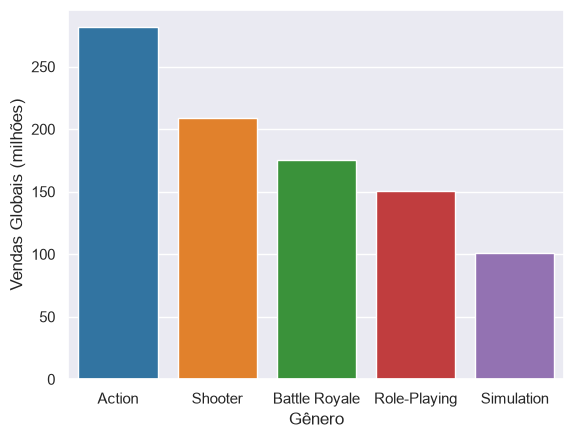

In [218]:
sns.barplot(data = top_5_generos,palette = 'tab10')

In [219]:
jogos_por_ano = df.groupby('Ano')

In [220]:
ja_series = jogos_por_ano['Nome'].count()

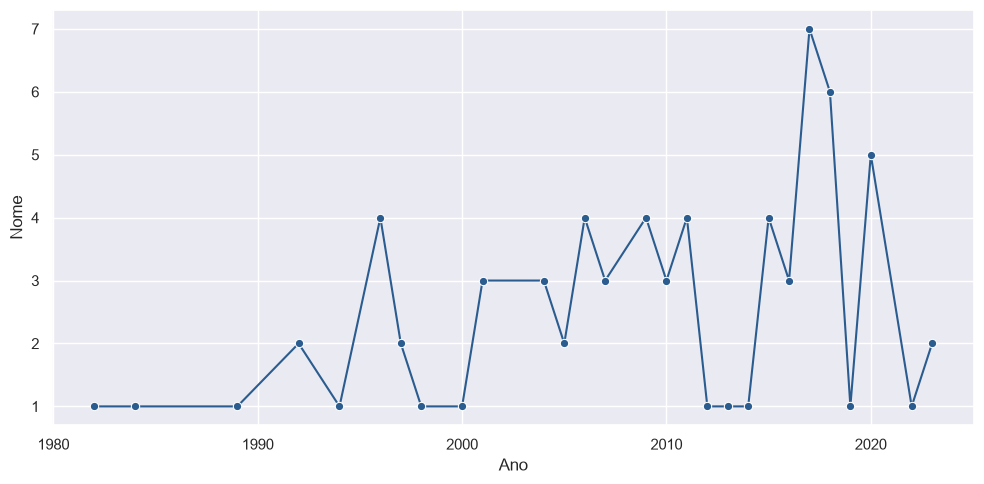

In [221]:
plt.figure(figsize=(10, 5))  
sns.set_theme(style="darkgrid") 
sns.lineplot(data=ja_series, marker='o', color='#2b5c8f')

plt.tight_layout()
plt.show()